In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

print("✅ Libraries Imported Successfully!")

✅ Libraries Imported Successfully!


In [9]:
model = load_model("../models/emotionsense_best.keras")

print("✅ Best Model Loaded Successfully!")


✅ Best Model Loaded Successfully!


In [10]:
emotion_labels = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

print(emotion_labels)

['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']


✅ Image Loaded Successfully!


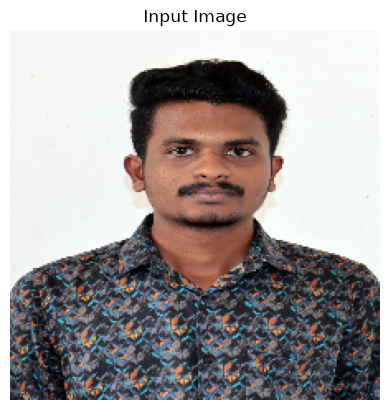

In [11]:
image_path = "../test_images/person1.jpg.jpeg"

img = image.load_img(
    image_path,
    target_size=(224, 224)
)

plt.imshow(img)
plt.axis("off")
plt.title("Input Image")

print("✅ Image Loaded Successfully!")


In [12]:
img_array = image.img_to_array(img)

print("Shape :", img_array.shape)
print("Data Type :", img_array.dtype)

Shape : (224, 224, 3)
Data Type : float32


In [13]:
img_array = np.expand_dims(img_array, axis=0)

print("New Shape :", img_array.shape)

New Shape : (1, 224, 224, 3)


In [14]:
img_array = img_array / 255.0

print("Maximum Pixel :", img_array.max())
print("Minimum Pixel :", img_array.min())

Maximum Pixel : 1.0
Minimum Pixel : 0.0


In [15]:
prediction = model.predict(img_array)

print("Prediction Shape:", prediction.shape)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction Shape: (1, 7)
[[0.16583884 0.06053618 0.1690888  0.12286507 0.18169324 0.11460503
  0.18537283]]


In [16]:
predicted_index = np.argmax(prediction)

print("Predicted Index:", predicted_index)

Predicted Index: 6


In [17]:
predicted_emotion = emotion_labels[predicted_index]

print("Predicted Emotion:", predicted_emotion)

Predicted Emotion: Surprise


In [18]:
confidence = np.max(prediction) * 100

print(f"Confidence: {confidence:.2f}%")

Confidence: 18.54%


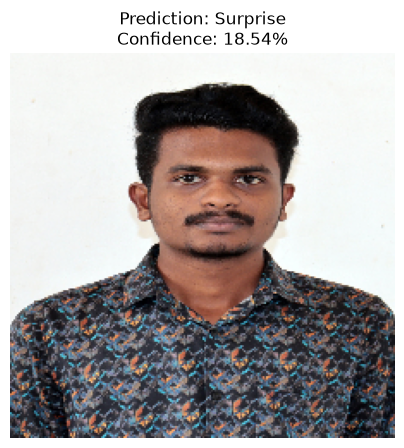

In [20]:
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_emotion}\nConfidence: {confidence:.2f}%")

plt.show()